Dataset shape: (150, 5)

Columns:
 Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

Accuracy: 0.9666666666666667

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



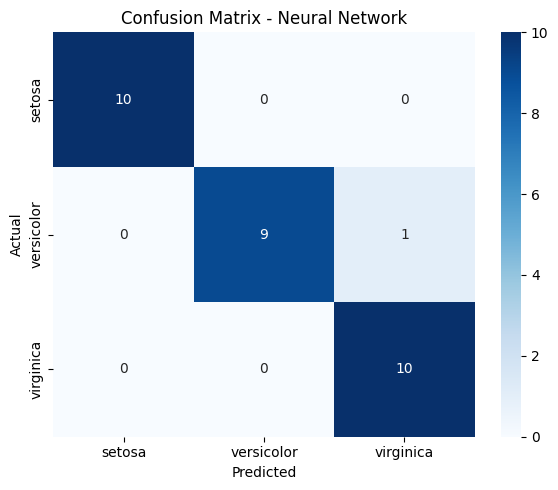


Neural network classification completed successfully.


In [1]:
# Level 3 - Task 3
# Neural Network Classification using Iris Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# load dataset
df = pd.read_csv("../datasets/iris.csv")

print("Dataset shape:", df.shape)
print("\nColumns:\n", df.columns)

# separate features and target
X = df.drop("species", axis=1)
y = df["species"]

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# neural network model
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=500,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# predictions
y_pred = model.predict(X_test_scaled)

# evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title("Confusion Matrix - Neural Network")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("\nNeural network classification completed successfully.")